In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow

In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)


In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="XIVXH729e8RRherXtIB7")
project = rf.workspace("ssz").project("aim-final")
version = project.version(4)
dataset = version.download("yolov11")

In [ ]:
dataset.location

'/content/AIM-final-4'

In [ ]:
!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=50 imgsz=640 plots=True

100% 18.4M/18.4M [00:00<00:00, 224MB/s]
New https://pypi.org/project/ultralytics/8.3.178 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/AIM-final-4/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_mask

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,430,602 parameters, 0 gradients, 21.4 GFLOPs
val: Scanning /content/AIM-final-4/valid/labels.cache... 84 images, 10 backgrounds, 0 corrupt: 100% 84/84 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 6/6 [00:03<00:00,  1.71it/s]
                   all         84        945      0.777      0.765      0.773      0.735
                   7up         14         69      0.763      0.957      0.844      0.819
                    BM          7         14      0.804      0.877      0.869      0.825
                Bugles          7         13      0.593      0.615      0.512      0.497
             Cheetos C         14         14       0.72      0.714      0.795      0.726
           Cheetos Hot         15         19      0.629      0.526      0.559      0.488
                  Cola         18         80      0.7

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:20]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [ ]:
import cv2
from ultralytics import YOLO


0: 640x640 6 7ups, 5 Colas, 7 mirindas, 9 pepsis, 15.7ms
Speed: 3.2ms preprocess, 15.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


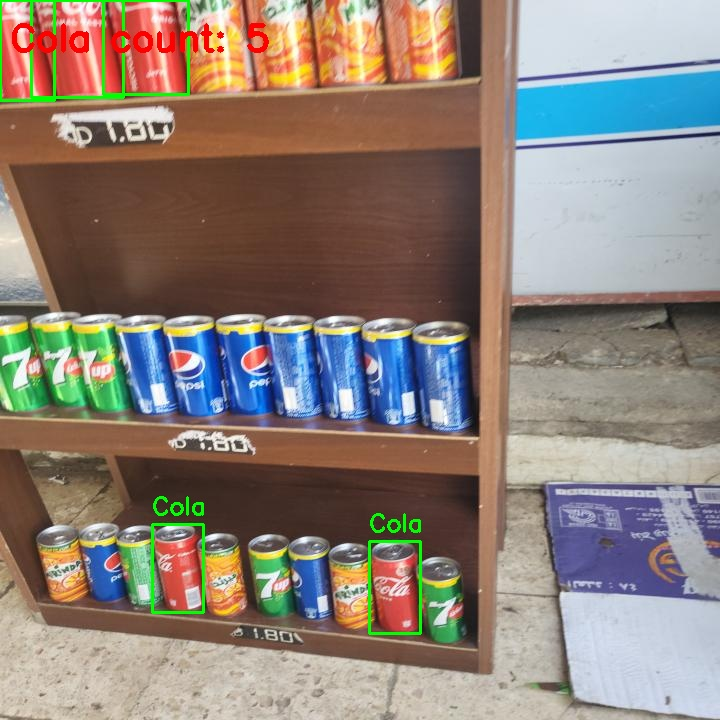

 Cola موجود است (5 عدد شناسایی شد)


In [ ]:
from ultralytics import YOLO
import cv2
from IPython.display import display, Image as IPyImage

# بارگذاری مدل فاین‌تیون‌شده
model = YOLO("/content/runs/detect/train/weights/best.pt")

# بارگذاری تصویر
image_path = "/content/AIM-final-4/test/images/20230511_141814_052_saved_jpg.rf.377eb2b2e05b87b755fe611f901f121e.jpg"

image = cv2.imread(image_path)

# پیش‌بینی با مدل
results = model(image)  # returns list of Results

# شمارش تعداد Cola و گرفتن مختصات جعبه‌ها
cola_count = 0
for result in results:  # معمولاً فقط یک result
    boxes = result.boxes
    for i, box in enumerate(boxes):
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        if class_name.lower() == "cola":
            cola_count += 1
            # گرفتن مختصات جعبه
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            # رسم جعبه روی تصویر
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            # نوشتن نام کلاس روی جعبه
            cv2.putText(image, class_name, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

# چاپ تعداد Cola روی تصویر
cv2.putText(image, f"Cola count: {cola_count}", (10, 50),
            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

# ذخیره و نمایش تصویر نهایی
output_path = "/content/result_colas.jpg"
cv2.imwrite(output_path, image)
display(IPyImage(filename=output_path, width=600))

# پیام هشدار یا تایید
if cola_count == 0:
    print(" هشدار: Cola در قفسه موجود نیست!")
else:
    print(f" Cola موجود است ({cola_count} عدد شناسایی شد)")


In [ ]:
from ultralytics import YOLO
import cv2

# بارگذاری مدل فاین‌تیون‌شده
model = YOLO("/content/runs/detect/train/weights/best.pt")

# مسیر ویدیو ورودی و خروجی
video_path = "/content/test_video.mp4"
output_path = "/content/result_video.mp4"

# بارگذاری ویدیو
cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# آماده‌سازی ویدیو خروجی
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # پیش‌بینی روی هر فریم
    results = model(frame)

    cola_count = 0
    for result in results:
        boxes = result.boxes
        for box in boxes:
            class_id = int(box.cls[0])
            class_name = model.names[class_id]
            if class_name.lower() == "cola":
                cola_count += 1
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(frame, class_name, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    # چاپ تعداد Cola روی فریم
    cv2.putText(frame, f"Cola count: {cola_count}", (10, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

    # نوشتن فریم روی ویدیو خروجی
    out.write(frame)

    # نمایش زنده فریم (اختیاری)
    cv2.imshow("Cola Detection", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
out.release()
cv2.destroyAllWindows()
print(f"ویدیو خروجی ذخیره شد: {output_path}")
